## Importación de librerías

In [27]:
import seaborn as sns
import pandas as pd
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

%matplotlib inline

sns.set_theme()


## Carga, agregación a 90 días y purga de datos sensibles

In [28]:
# 1. Cargar datos
vle_df = pd.read_csv('./../../../dataset/oulad/studentVle.csv')
info_df = pd.read_csv('./../../../dataset/oulad/studentInfo.csv')

vle_90_days = vle_df[vle_df['date'] <= 90]
vle_agg = vle_90_days.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    mean_clicks=('sum_click', 'mean'),
    active_days=('date', 'nunique')
).reset_index()

vle_agg.fillna(0, inplace=True)

# 3. Excluir datos sensibles
sensitive_columns = ['gender', 'disability', 'age_band', 'imd_band', 'region']
info_clean = info_df.drop(columns=sensitive_columns)

## Cruce de datos y creación del Target

In [29]:

df_merged = pd.merge(info_clean, vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='inner')

# 2. Definir Agotamiento (Withdrawn = 1, Resto = 0)
df_merged['target_burnout'] = df_merged['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)

# Limpiar columnas innecesarias para el modelo (OJO: ya no borramos 'code_presentation' aquí)
df_merged = df_merged.drop(columns=['final_result', 'id_student'])

## Partición por cursos

In [34]:
df_train = df_merged[df_merged['code_presentation'].str.contains('2013')].copy()

df_test = df_merged[df_merged['code_presentation'].str.contains('2014')].copy()

columnas_a_borrar = ['code_module', 'code_presentation']

X_train = df_train.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']

X_test = df_test.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

print(f"Alumnos en Histórico (Train 2013): {len(X_train)}")
print(f"Alumnos Nuevos (Test 2014): {len(X_test)}")

Alumnos en Histórico (Train 2013): 12192
Alumnos Nuevos (Test 2014): 16966


## Construcción y Entrenamiento del Pipeline

In [40]:
cat_cols = ['highest_education']
num_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_clicks', 'active_days']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=1,
        n_estimators=100, 
        scale_pos_weight=3, 
        eval_metric='logloss',     
        random_state=42,           
        n_jobs=-1
    ))
])

# Entrenar modelo definitivo
xgb_pipeline.fit(X_train, y_train)

y_probs_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("¡Modelo XGBoost entrenado con hiperparámetros óptimos!")

¡Modelo XGBoost entrenado con hiperparámetros óptimos!


## Evaluación y Gráficas de Rendimiento

--- REPORTE DE CLASIFICACIÓN DETALLADO (XGBoost - Umbral: 0.4) ---
              precision    recall  f1-score   support

           0       0.86      0.63      0.73     12412
           1       0.42      0.72      0.53      4554

    accuracy                           0.65     16966
   macro avg       0.64      0.67      0.63     16966
weighted avg       0.74      0.65      0.67     16966



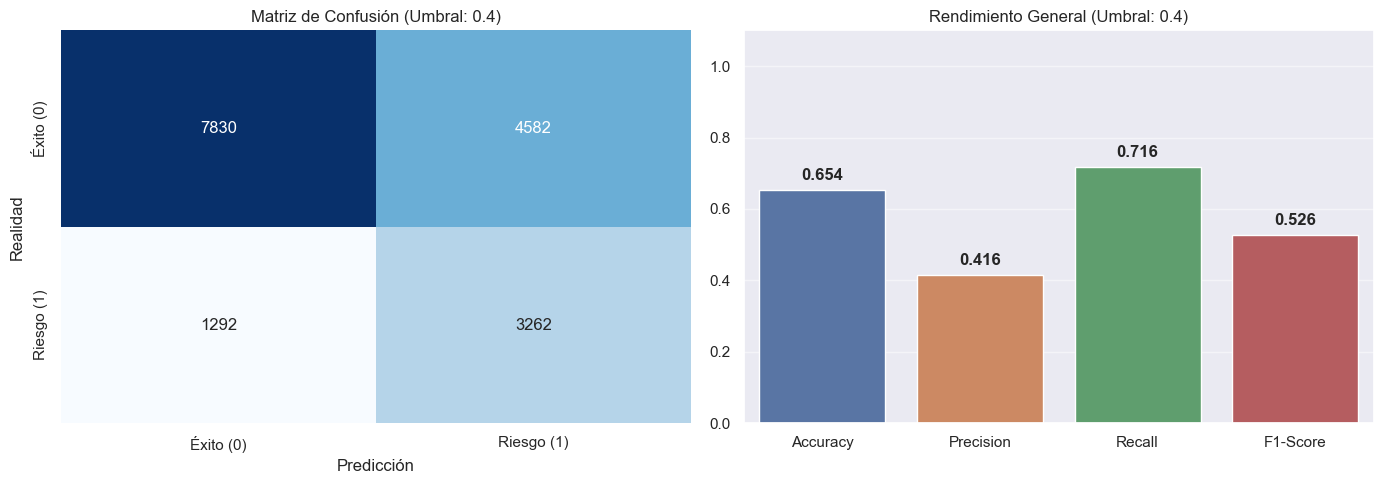

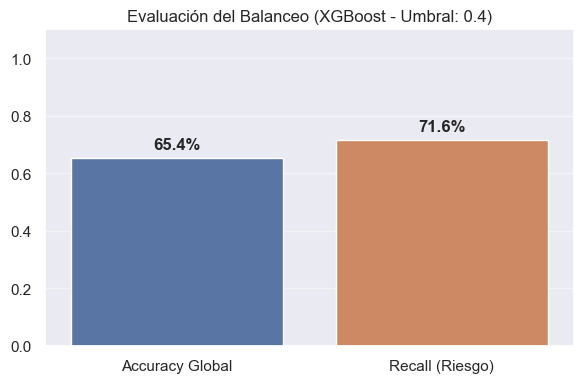

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


umbral_elegido = 0.40

# Generamos las predicciones finales aplicando el umbral a las probabilidades de XGBoost
y_pred = (y_probs_xgb >= umbral_elegido).astype(int)

# ==========================================
# 2. CÁLCULO DE MÉTRICAS Y REPORTE
# ==========================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"--- REPORTE DE CLASIFICACIÓN DETALLADO (XGBoost - Umbral: {umbral_elegido}) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# 3. GRÁFICOS: MÉTRICAS Y MATRIZ DE CONFUSIÓN
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
# Mostramos el umbral en el título
ax1.set_title(f'Matriz de Confusión (Umbral: {umbral_elegido})')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Realidad')

# Subplot 2: Métricas Habituales
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, legend=False, ax=ax2)
# Mostramos el umbral en el título
ax2.set_title(f'Rendimiento General (Umbral: {umbral_elegido})')
ax2.set_ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 4. GRÁFICO: Accuracy vs Recall Minoritario
# ==========================================
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

plt.figure(figsize=(6, 4))
metric_names_comp = ['Accuracy Global', 'Recall (Riesgo)']
metric_values_comp = [acc, burnout_recall]

ax3 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, legend=False)
# Mostramos el umbral en el título
plt.title(f'Evaluación del Balanceo (XGBoost - Umbral: {umbral_elegido})')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax3.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()